In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(8)

IMAGE_SIZE = 224
BATCH_SIZE = 32

print(f"🖥️ Device: {device}")
if device.type == 'cuda':
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM: {torch.cuda.get_device_properties(0).total_mem / 1024**3:.1f} GB")
print(f"📐 Image Size: {IMAGE_SIZE} | Batch: {BATCH_SIZE}")

🖥️ Device: cpu
🔢 CPU Threads: 8
📐 Image Size: 128 | Batch: 16


In [2]:
import os

# ✅ Hardcoded to your exact path — no guessing
BASE_DIR  = r"C:\Users\Rushikesh\OneDrive\CODES\SelfHealingNN"
data_dir  = os.path.join(BASE_DIR, 'medical_data')
train_dir = os.path.join(data_dir, 'train')
test_dir  = os.path.join(data_dir, 'test')
val_dir   = os.path.join(data_dir, 'val')

os.chdir(BASE_DIR)  # Set working directory so model saves work too

print("✅ Working from:", os.getcwd())
print("\n📂 Checking folders:")
for name, path in [("medical_data", data_dir), ("train", train_dir), ("test", test_dir), ("val", val_dir)]:
    status = "✅" if os.path.exists(path) else "❌ MISSING"
    print(f"   {status} {name}: {path}")

✅ Working from: C:\Users\Rushikesh\OneDrive\CODES\SelfHealingNN

📂 Checking folders:
   ✅ medical_data: C:\Users\Rushikesh\OneDrive\CODES\SelfHealingNN\medical_data
   ✅ train: C:\Users\Rushikesh\OneDrive\CODES\SelfHealingNN\medical_data\train
   ✅ test: C:\Users\Rushikesh\OneDrive\CODES\SelfHealingNN\medical_data\test
   ✅ val: C:\Users\Rushikesh\OneDrive\CODES\SelfHealingNN\medical_data\val


In [ ]:
# ✅ Enhanced augmentations for better generalization
# NO Normalize — keeps data in [0, 1] range to match VAE sigmoid output
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

print("✅ Transforms ready (enhanced augmentation, [0,1] range for VAE compatibility)")

✅ Transforms ready (no Normalize — [0,1] range for VAE compatibility)


In [ ]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_dataset  = datasets.ImageFolder(root=test_dir,  transform=test_transforms)
val_dataset   = datasets.ImageFolder(root=val_dir,   transform=test_transforms)

# ⚖️ Fix class imbalance with WeightedRandomSampler
targets = np.array(train_dataset.targets)
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts
sample_weights = class_weights[targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0, pin_memory=True)

print(f"✅ Train: {len(train_dataset)} images")
print(f"✅ Test : {len(test_dataset)}  images")
print(f"✅ Val  : {len(val_dataset)}   images")
print(f"🏷️  Classes: {train_dataset.classes}")
print(f"⚖️  Distribution: {dict(zip(train_dataset.classes, class_counts))}")
print(f"⚖️  WeightedRandomSampler active — balanced training!")

✅ Train: 5216 images
✅ Test : 624  images
✅ Val  : 16   images
🏷️  Classes: ['NORMAL', 'PNEUMONIA']
⚖️  Distribution: {'NORMAL': np.int64(1341), 'PNEUMONIA': np.int64(3875)}
⚖️  WeightedRandomSampler active — balanced training!


In [5]:
def add_medical_noise(image_tensor, noise_factor=0.3):
    """Simulates low-radiation X-ray static noise."""
    noise = torch.randn_like(image_tensor) * noise_factor
    return torch.clamp(image_tensor + noise, 0., 1.)

print("✅ Noise function ready")

✅ Noise function ready


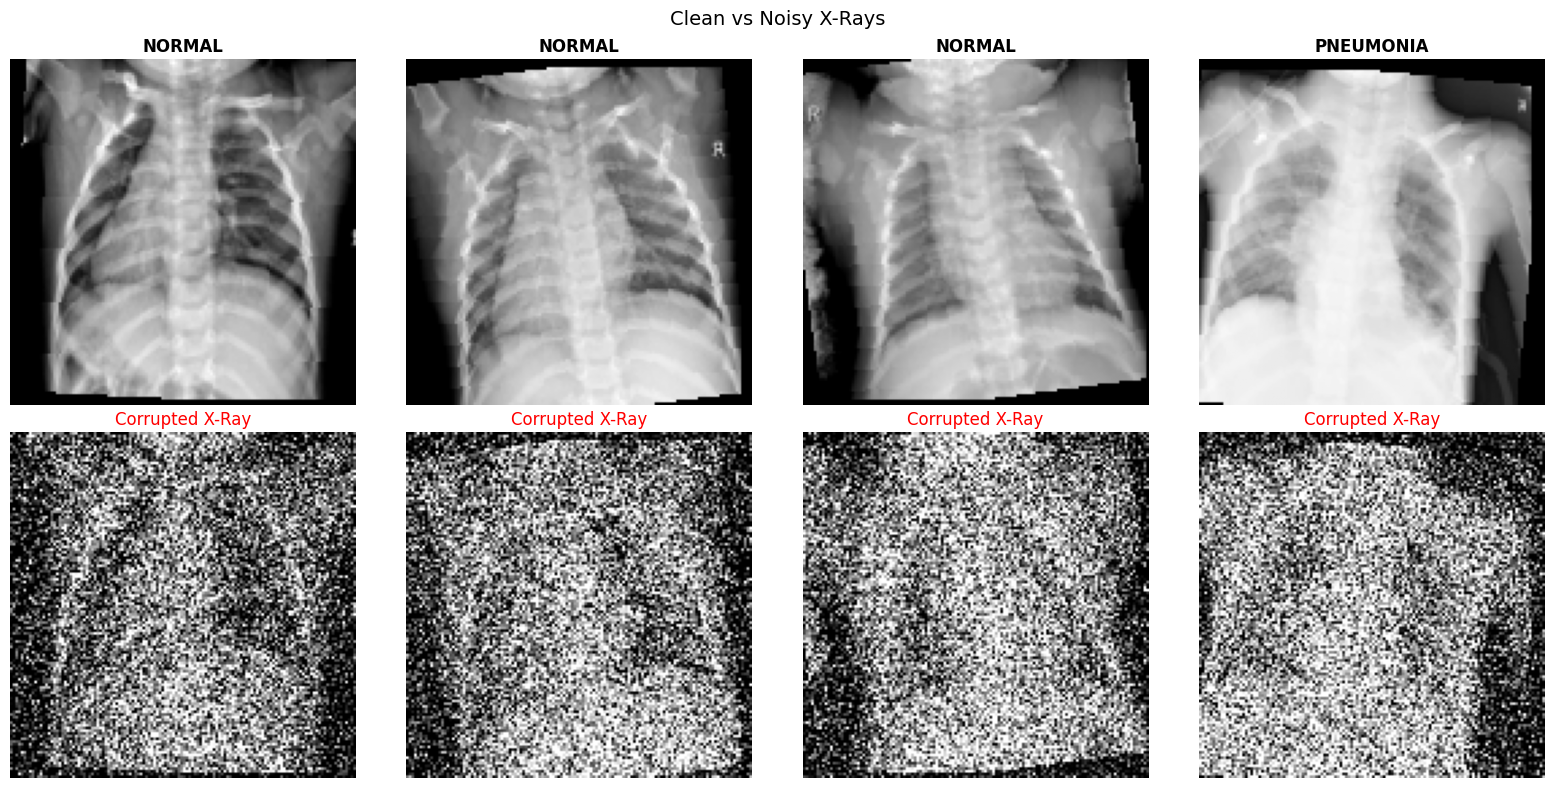

In [6]:
images, labels = next(iter(train_loader))
noisy_images   = add_medical_noise(images, 0.4)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
class_names = train_dataset.classes

for i in range(4):
    img = images[i].squeeze()
    noisy = noisy_images[i].squeeze()

    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(class_names[labels[i]], fontsize=12, fontweight='bold')
    axes[0, i].axis('off')

    axes[1, i].imshow(noisy, cmap='gray')
    axes[1, i].set_title("Corrupted X-Ray", color='red')
    axes[1, i].axis('off')

plt.suptitle("Clean vs Noisy X-Rays", fontsize=14)
plt.tight_layout()
plt.show()